In [1]:
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

from gwfast.lensing_utils_alt import \
    get_agn_lens_angles, PML_time_delay_magnification

In [2]:
n = 50
shape = (n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 
    'dL':np.full(shape, 1), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
}
events = {key: val.astype(np.float64) for key, val in events.items()}

src_pos_array = np.geomspace(0.02, 0.99, n)
M_lz_array = np.geomspace(1e4, 1e6, n)

src_pos_mesh, M_lz_mesh = np.meshgrid(src_pos_array, M_lz_array, indexing='xy')
events['src_pos'] = src_pos_mesh
events['M_lz'] = M_lz_mesh

In [3]:
theta_E, beta, _ = get_agn_lens_angles(
        events['M_lz'], events['R_orbit'], 
        events['src_pos'], events['dL'],
    )
time_delay, _, _ = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)
time_delay = - onp.asarray(time_delay)

Text(0, 0.5, '$M_{Lz}\\,/\\,M_{\\odot}$')

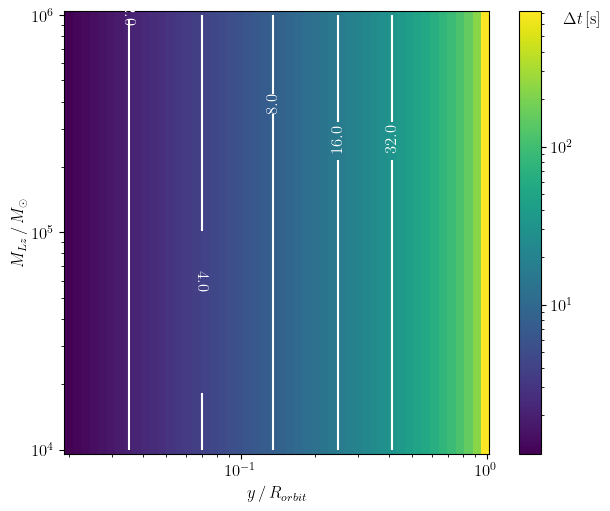

In [9]:
time_delay_levels = [2, 4, 8, 16, 32]

fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im = ax.pcolormesh(src_pos_array, M_lz_array, time_delay, 
                        # vmin=vmin0, vmax=vmax0,
                       norm=LogNorm()
                       )
cbar = fig.colorbar(im)
contour = ax.contour(src_pos_array, M_lz_array, time_delay, 
                         levels=time_delay_levels, colors='white')
ax.clabel(contour, fmt='%1.1f', colors='white')
cbar.set_label(r'$\Delta t\,[\mathrm{s}]$', labelpad=20, loc='top', rotation=0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$y\,/\,R_{orbit}$')
ax.set_ylabel(r'$M_{Lz}\,/\,M_{\odot}$')